# GFDL vertical profiles: forced-ocean parameterization comparison

Regional **vertical profiles** of temperature, salinity, and potential
density ($\sigma_2$), extending the horizontal (surface / 100 m) regional
bias diagnostics in `gfdl_regional_biases.ipynb` with the full depth
dimension -- mirroring CESM's `vertical_profiles.ipynb`. A simplified set
of five basin-scale regions (broader than `gfdl_regional_biases.ipynb`'s
boundary-current-focused ones). Uses the same `*_thetao_time_mean.nc`/
`*_so_time_mean.nc` bias fields already in `data/gfdl_1988_2012/` -- no new
computation, just a region/depth-averaged summary of data already computed.

**Kernel:** `env-from-npl-2024a` (Python 3.11.6).

In [1]:
%load_ext autoreload
%autoreload 2

import warnings
warnings.filterwarnings('ignore')

import os

import numpy as np
import xarray as xr
import matplotlib as mpl
import matplotlib.pyplot as plt
import gsw

from experiment import Experiment

%matplotlib inline

plt.rcParams['figure.figsize'] = (15, 5)
plt.rcParams.update({'font.size': 16})

REPO = os.path.abspath(os.path.join(os.getcwd(), '..'))
YAML_DIR = os.path.join(REPO, 'yamls')
GFDL_DIR = os.path.join(REPO, 'data', 'gfdl_1988_2012')

print('REPO     =', REPO)
print('GFDL_DIR =', GFDL_DIR)

REPO     = /glade/u/home/pavelp/m2lines-CESM3-diagnostics
GFDL_DIR = /glade/u/home/pavelp/m2lines-CESM3-diagnostics/data/gfdl_1988_2012


In [2]:
experiment_defs = [
    ('gfdl_CTRL',       GFDL_DIR),
    ('gfdl_bANN',       GFDL_DIR),
    ('gfdl_uANN',       GFDL_DIR),
    ('gfdl_bANN_uANN',  GFDL_DIR),
]

exps = {}
for name, folder in experiment_defs:
    yaml_path = os.path.join(YAML_DIR, f'{name}.yaml')
    exps[name] = Experiment(yaml_path, folder=folder, name=name,
                            load_grid=True, verbose=True)

names = list(exps.keys())
CTRL = 'gfdl_CTRL'

LABELS = {
    'gfdl_CTRL':      'CTRL',
    'gfdl_bANN':      'bANN',
    'gfdl_uANN':      'uANN',
    'gfdl_bANN_uANN': 'bANN_uANN',
}
COLORS = {
    'gfdl_CTRL':      'k',
    'gfdl_bANN':      '#0072B2',
    'gfdl_uANN':      '#E69F00',
    'gfdl_bANN_uANN': '#009E73',
}

print('Initialized:', names)

[gfdl_CTRL] casename=gfdl_CTRL, rundir=/glade/derecho/scratch/pavelp/GFDL/CTRL/cesm_format/run


ERROR 1: PROJ: proj_create_from_database: Open of /glade/work/pavelp/conda-envs/env-from-npl-2024a/share/proj failed


MOM6 grid successfully loaded... 



[gfdl_bANN] casename=gfdl_bANN, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN/cesm_format/run
MOM6 grid successfully loaded... 



[gfdl_uANN] casename=gfdl_uANN, rundir=/glade/derecho/scratch/pavelp/GFDL/uANN/cesm_format/run
MOM6 grid successfully loaded... 



[gfdl_bANN_uANN] casename=gfdl_bANN_uANN, rundir=/glade/derecho/scratch/pavelp/GFDL/bANN_uANN/cesm_format/run
MOM6 grid successfully loaded... 

Initialized: ['gfdl_CTRL', 'gfdl_bANN', 'gfdl_uANN', 'gfdl_bANN_uANN']


# 1. Analysis regions

A simplified set of five basin-scale regions (broader than
`gfdl_regional_biases.ipynb`'s boundary-current-focused ones), matching
CESM's `vertical_profiles.ipynb`: Global Ocean, Tropical Pacific,
Southern Ocean, Indian Ocean, North Atlantic.

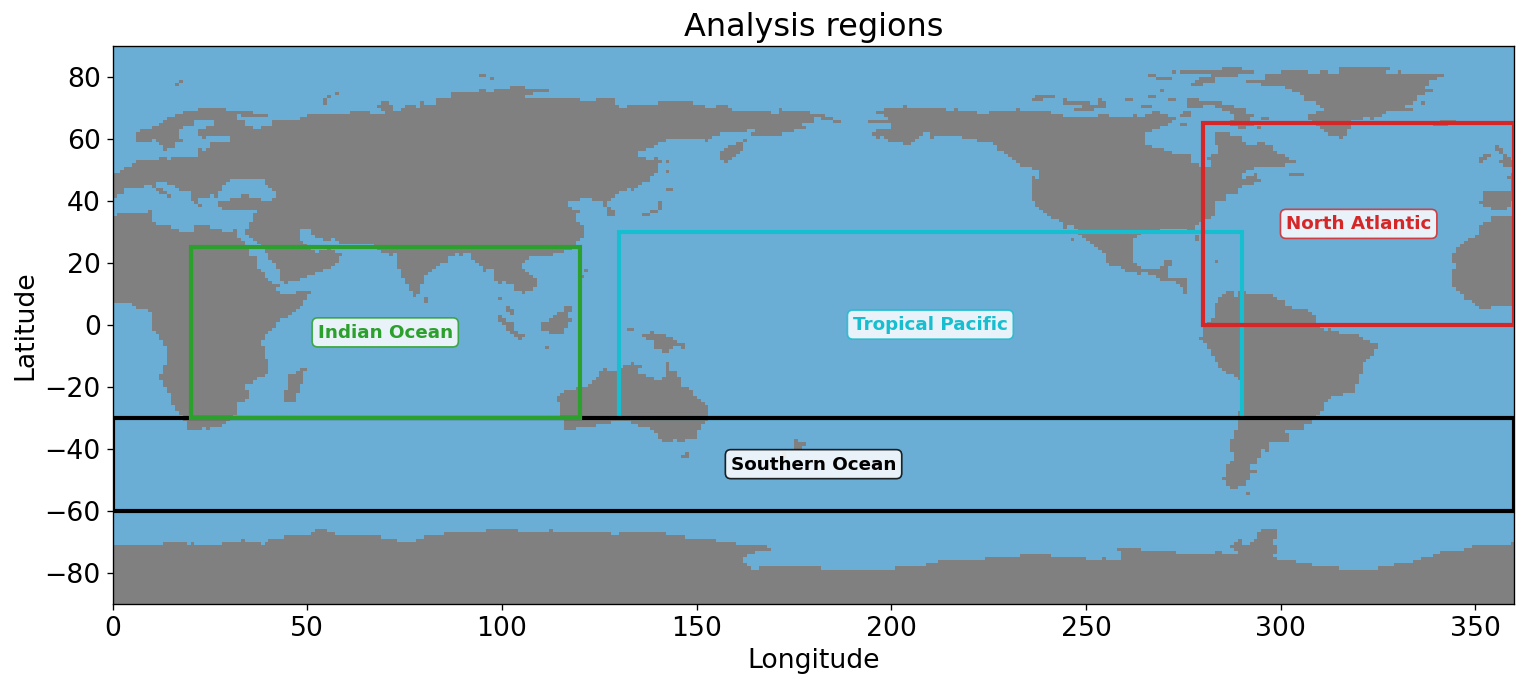

In [3]:
REGIONS = {
    'Global Ocean':     None,
    'Tropical Pacific': (-30,  30, 130, 290),
    'Southern Ocean':   (-60, -30,   0, 360),
    'Indian Ocean':     (-30,  25,  20, 120),
    'North Atlantic':   (  0,  65, 280, 360),
}
REGION_NAMES = list(REGIONS.keys())
REGION_COLORS = {
    'Tropical Pacific': 'tab:cyan',
    'Southern Ocean':   'k',
    'Indian Ocean':     'tab:green',
    'North Atlantic':   'tab:red',
}


def region_mask(exp, region):
    """Boolean DataArray (yh, xh) selecting grid cells inside `region`.
    GFDL's grid is regular 1x1deg, so xh/yh ARE longitude/latitude exactly."""
    if REGIONS[region] is None:
        return exp.grd.wet > 0
    s, n, w, e = REGIONS[region]
    lat = exp.grd.yh
    lon360 = exp.grd.xh % 360.0
    return (lat >= s) & (lat <= n) & (lon360 >= w) & (lon360 <= e) & (exp.grd.wet > 0)


fig, ax = plt.subplots(figsize=(13, 6), dpi=120)
exp = exps[CTRL]
ax.pcolormesh(exp.grd.xh.values, exp.grd.yh.values,
             np.where(exp.grd.wet.values > 0, 1.0, np.nan),
             cmap='Blues', vmin=0, vmax=2, shading='auto')
ax.set_facecolor('gray')
for name, box in REGIONS.items():
    if box is None:
        continue
    s, n, w, e = box
    color = REGION_COLORS[name]
    rect = plt.Rectangle((w, s), e - w, n - s, linewidth=2.5,
                         edgecolor=color, facecolor='none', zorder=5)
    ax.add_patch(rect)
    ax.text(0.5 * (w + e), 0.5 * (s + n), name, color=color, fontsize=11,
           fontweight='bold', ha='center', va='center',
           bbox=dict(boxstyle='round', fc='white', ec=color, alpha=0.85), zorder=6)
ax.set_xlabel('Longitude')
ax.set_ylabel('Latitude')
ax.set_title('Analysis regions')
plt.tight_layout()
plt.show()

# 2. Shared depth axis and variable helpers

The piecewise-stretched depth axis (0-200 / 200-1000 / 1000-5500 m each get
1/3 of the panel height) and the WOA-2018 recovery (`obs_sigma2`, model -
bias) are ported verbatim from `gfdl_vertical_sections.ipynb`.
`region_profile`/`region_rmse_profile` are the area-weighted regional
analogue of that notebook's zonal average.

In [4]:
# Piecewise-linear depth axis: 0-200, 200-1000, 1000-5500 m each get 1/3 of the height
d_edges = [0, 200, 1000, 5500]

def _depth_forward(d):
    d = np.asarray(d, dtype=float)
    return np.where(d <= d_edges[1], (d - d_edges[0]) / (d_edges[1] - d_edges[0]) / 3,
           np.where(d <= d_edges[2], 1 / 3 + (d - d_edges[1]) / (d_edges[2] - d_edges[1]) / 3,
                    2 / 3 + (d - d_edges[2]) / (d_edges[3] - d_edges[2]) / 3))

def _depth_inverse(y):
    y = np.asarray(y, dtype=float)
    return np.where(y <= 1 / 3, d_edges[0] + y * 3 * (d_edges[1] - d_edges[0]),
           np.where(y <= 2 / 3, d_edges[1] + (y - 1 / 3) * 3 * (d_edges[2] - d_edges[1]),
                    d_edges[2] + (y - 2 / 3) * 3 * (d_edges[3] - d_edges[2])))

def _set_depth_axis(ax):
    ax.set_yscale('function', functions=(_depth_forward, _depth_inverse))
    ax.set_ylim(d_edges[3], d_edges[0])
    ax.set_yticks([0, 100, 200, 500, 1000, 2000, 3000, 4000, 5000, 5500])


def obs_sigma2(exp):
    # Observational sigma2 (WOA-2018) recovered from model field minus bias.
    t = exp.thetao()
    s = exp.so()
    thetao_obs = t.thetao - t.thetao_bias
    so_obs = s.so - s.so_bias
    return gsw.sigma2(so_obs, thetao_obs)


def bias_field(exp, var):
    # Model - WOA18 (z_l, yh, xh) field for 'thetao', 'so', or 'sigma2'.
    if var == 'thetao':
        return exp.thetao()['thetao_bias']
    if var == 'so':
        return exp.so()['so_bias']
    return exp.sigma2() - obs_sigma2(exp)


def region_profile(exp, region, field):
    # Area-weighted vertical profile of `field` (z_l, yh, xh) over `region` -> (z_l,).
    m = region_mask(exp, region) & field.notnull()
    w = exp.area.where(m)
    return (w * field).sum(['yh', 'xh']) / w.sum(['yh', 'xh'])


def region_rmse_profile(exp, region, bias):
    # Area-weighted RMSE vertical profile of a bias field (z_l, yh, xh) over `region` -> (z_l,).
    m = region_mask(exp, region) & bias.notnull()
    w = exp.area.where(m)
    return np.sqrt((w * bias ** 2).sum(['yh', 'xh']) / w.sum(['yh', 'xh']))


VARIABLES = [
    ('thetao', 'Temperature', r'$^\circ$C'),
    ('so', 'Salinity', 'psu'),
    ('sigma2', r'Potential density ($\sigma_2$)', 'kg m$^{-3}$'),
]

# 3. Regional vertical profiles vs WOA-2018

Area-weighted vertical **bias** profile (model $-$ WOA18) of temperature,
salinity and $\sigma_2$, one panel per region, all 4 experiments overlaid
(CTRL in black).

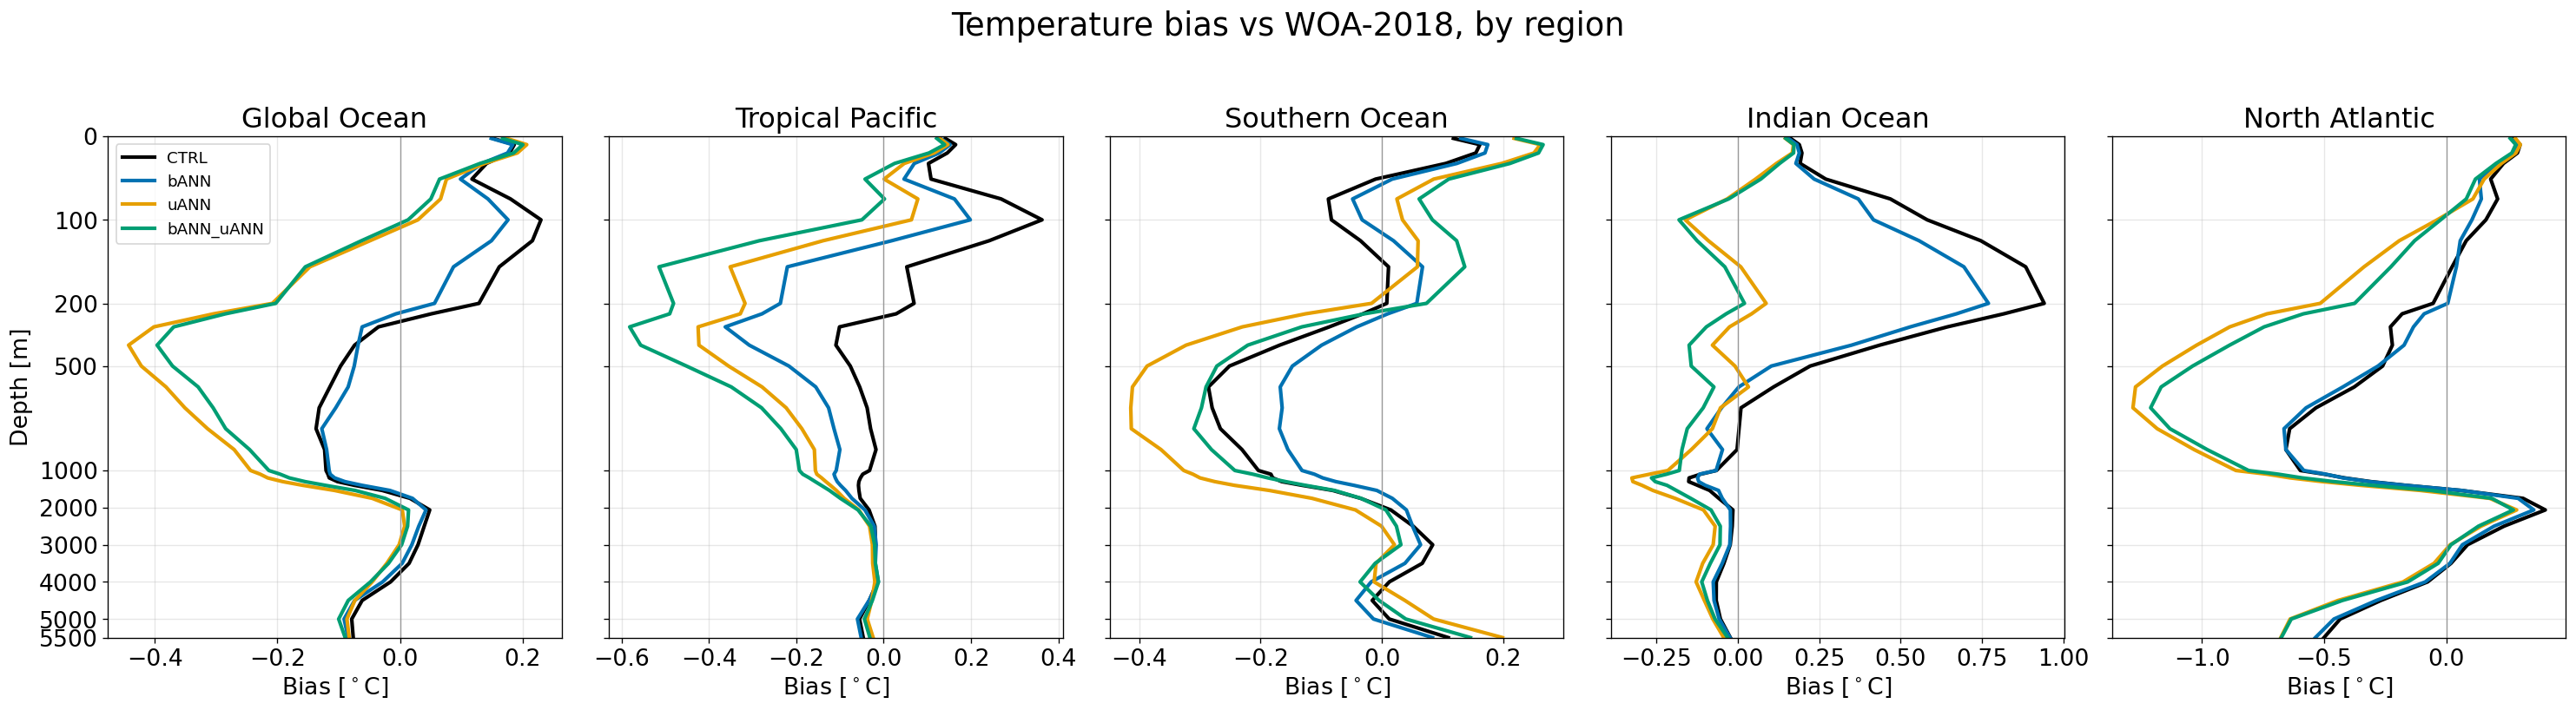

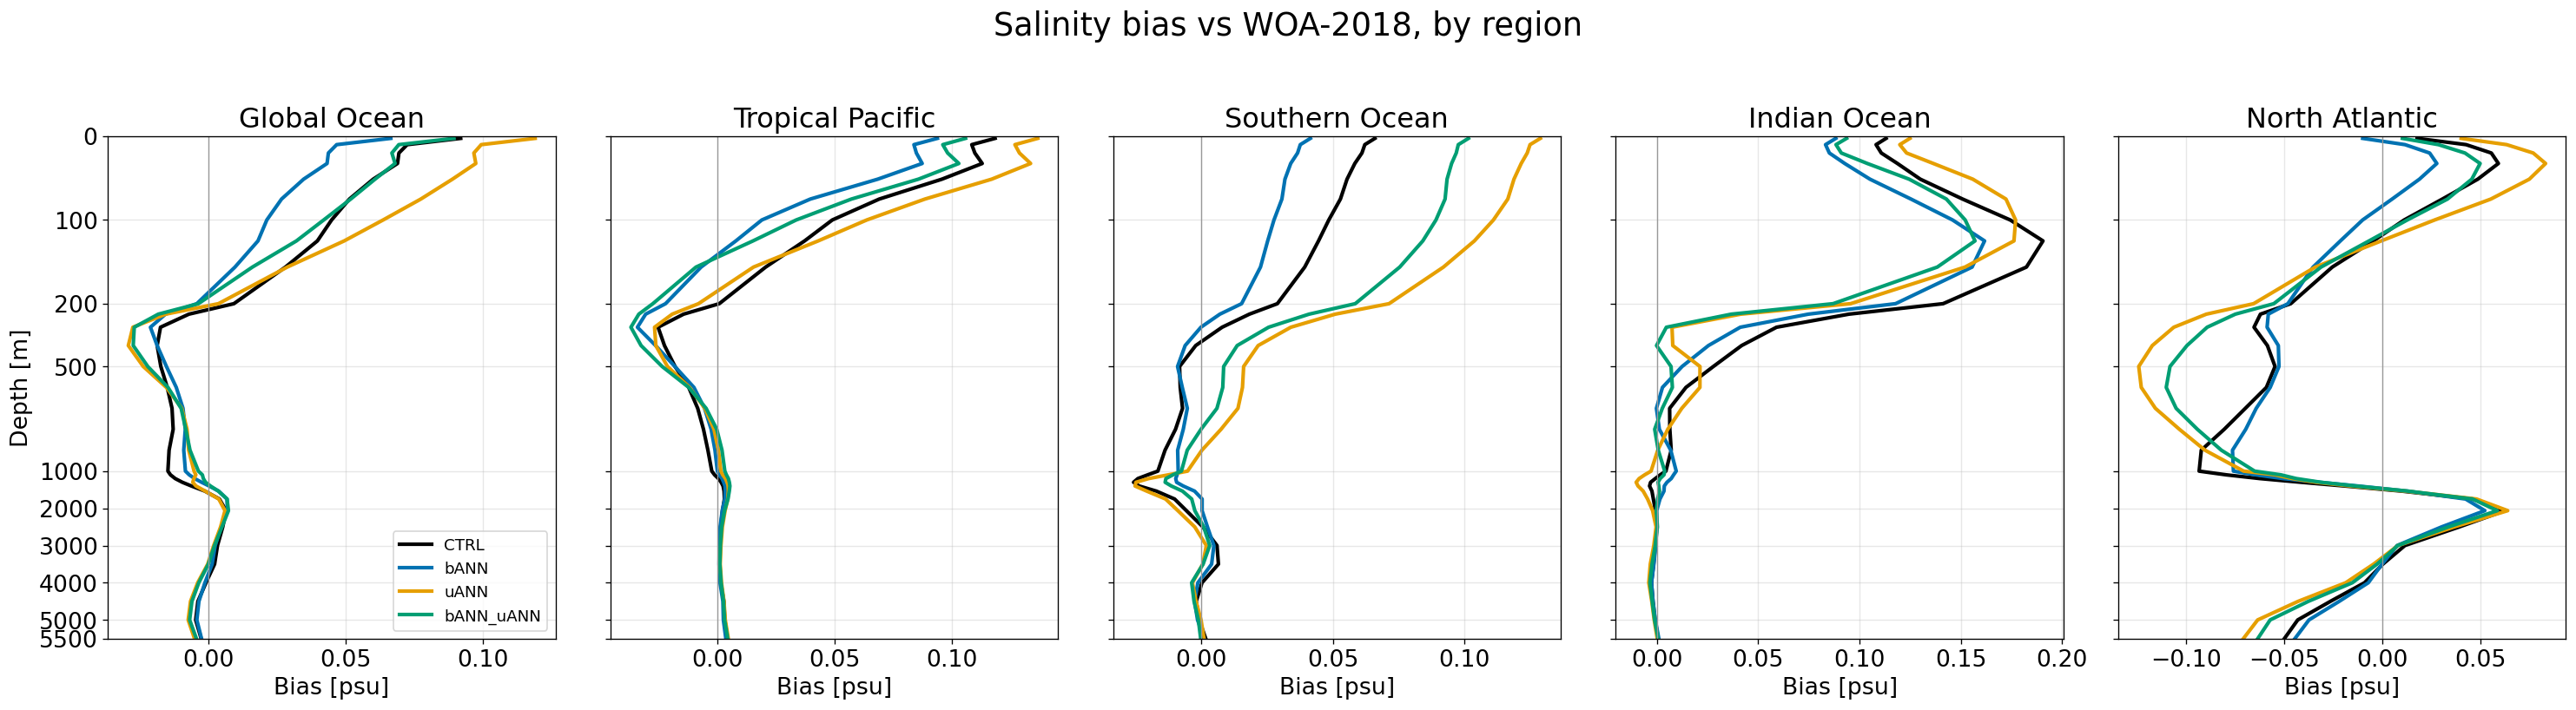

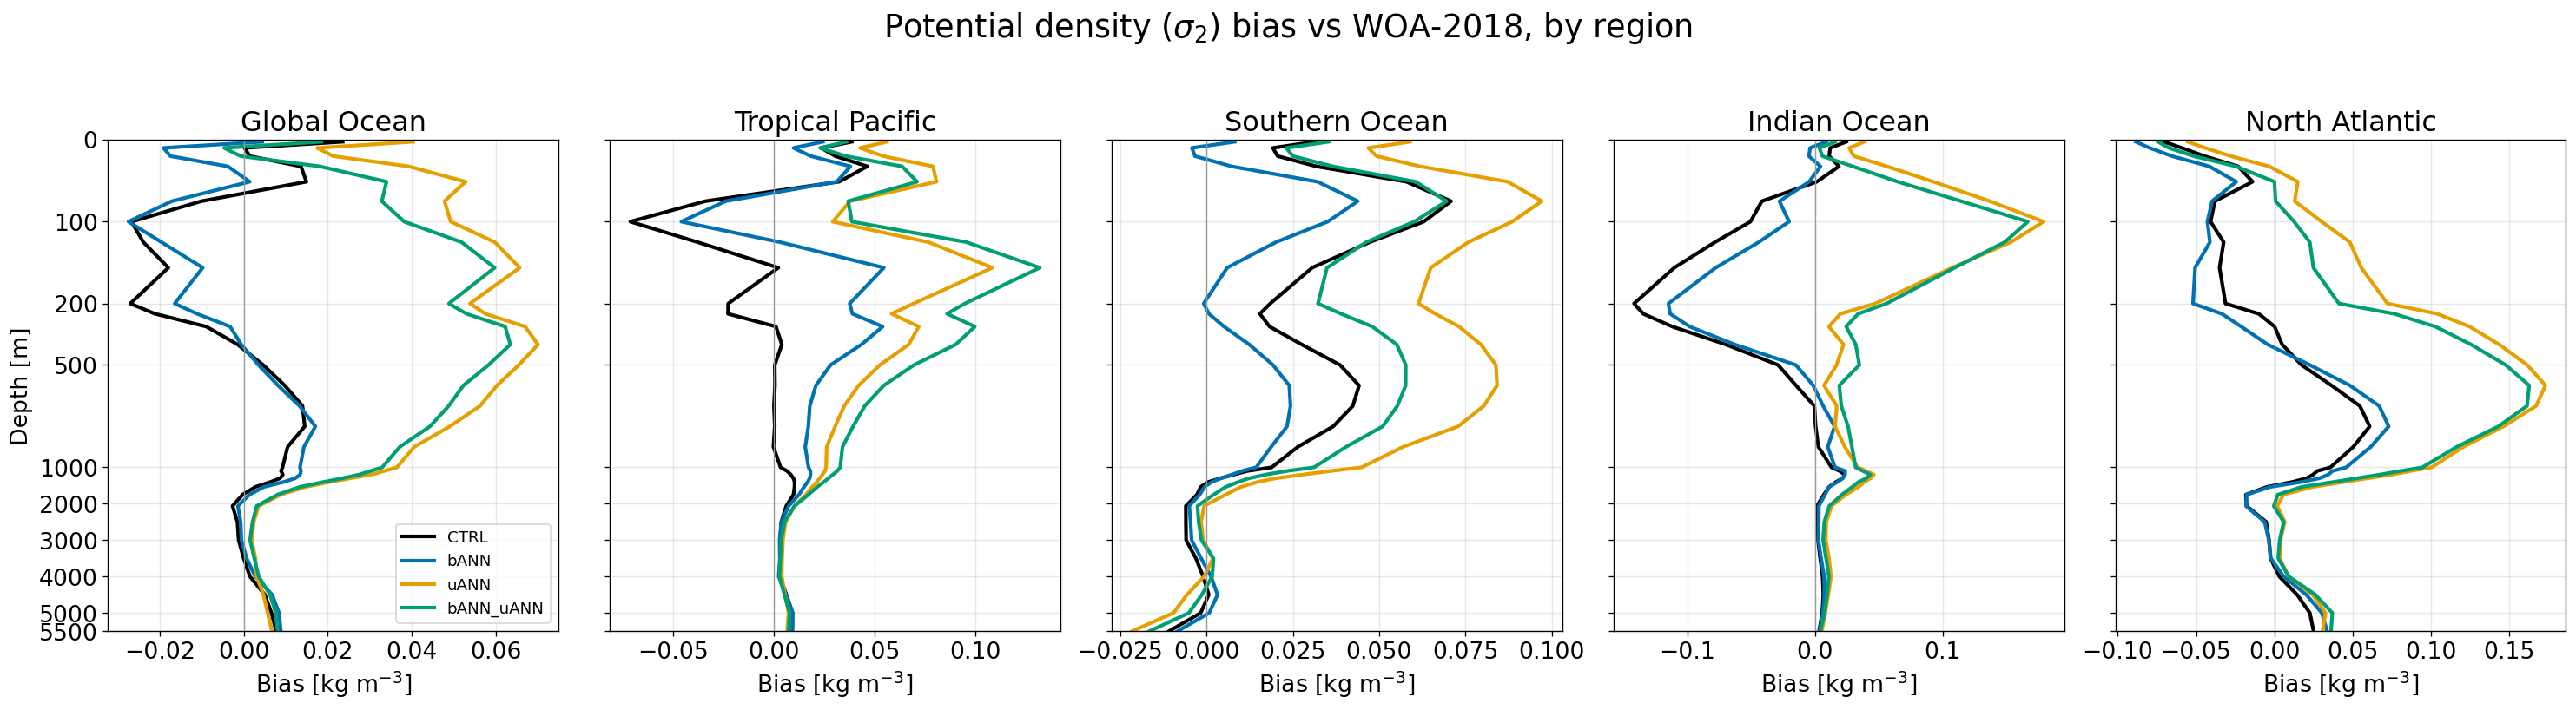

In [5]:
def plot_region_profiles(var, long_name, unit, mode='bias'):
    """1x5 row of vertical profiles (one panel per region), all 4
    experiments overlaid. mode='bias' plots the area-weighted mean bias
    (model - WOA18); mode='rmse' plots the area-weighted RMSE."""
    fields = {name: bias_field(exps[name], var) for name in names}
    fig, axes = plt.subplots(1, len(REGION_NAMES),
                             figsize=(5 * len(REGION_NAMES), 7), dpi=120, sharey=True)
    for col, region in enumerate(REGION_NAMES):
        ax = axes[col]
        for name in names:
            if mode == 'bias':
                prof = region_profile(exps[name], region, fields[name])
            else:
                prof = region_rmse_profile(exps[name], region, fields[name])
            prof.plot(ax=ax, y='z_l', color=COLORS[name], lw=2.5, label=LABELS[name])
        if mode == 'bias':
            ax.axvline(0, color='0.6', lw=0.8)
        _set_depth_axis(ax)
        ax.set_title(region)
        ax.set_xlabel(f'{"Bias" if mode == "bias" else "RMSE"} [{unit}]')
        ax.set_ylabel('Depth [m]' if col == 0 else '')
        ax.grid(True, alpha=0.3)
        if col == 0:
            ax.legend(fontsize=11)
    verb = 'bias' if mode == 'bias' else 'RMSE'
    fig.suptitle(f'{long_name} {verb} vs WOA-2018, by region', fontsize=22)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    plt.show()


for var, long_name, unit in VARIABLES:
    plot_region_profiles(var, long_name, unit, mode='bias')

# 4. RMSE vs depth, by region

Area-weighted RMSE (model vs. WOA-2018) as a function of depth, for
temperature, salinity and $\sigma_2$.

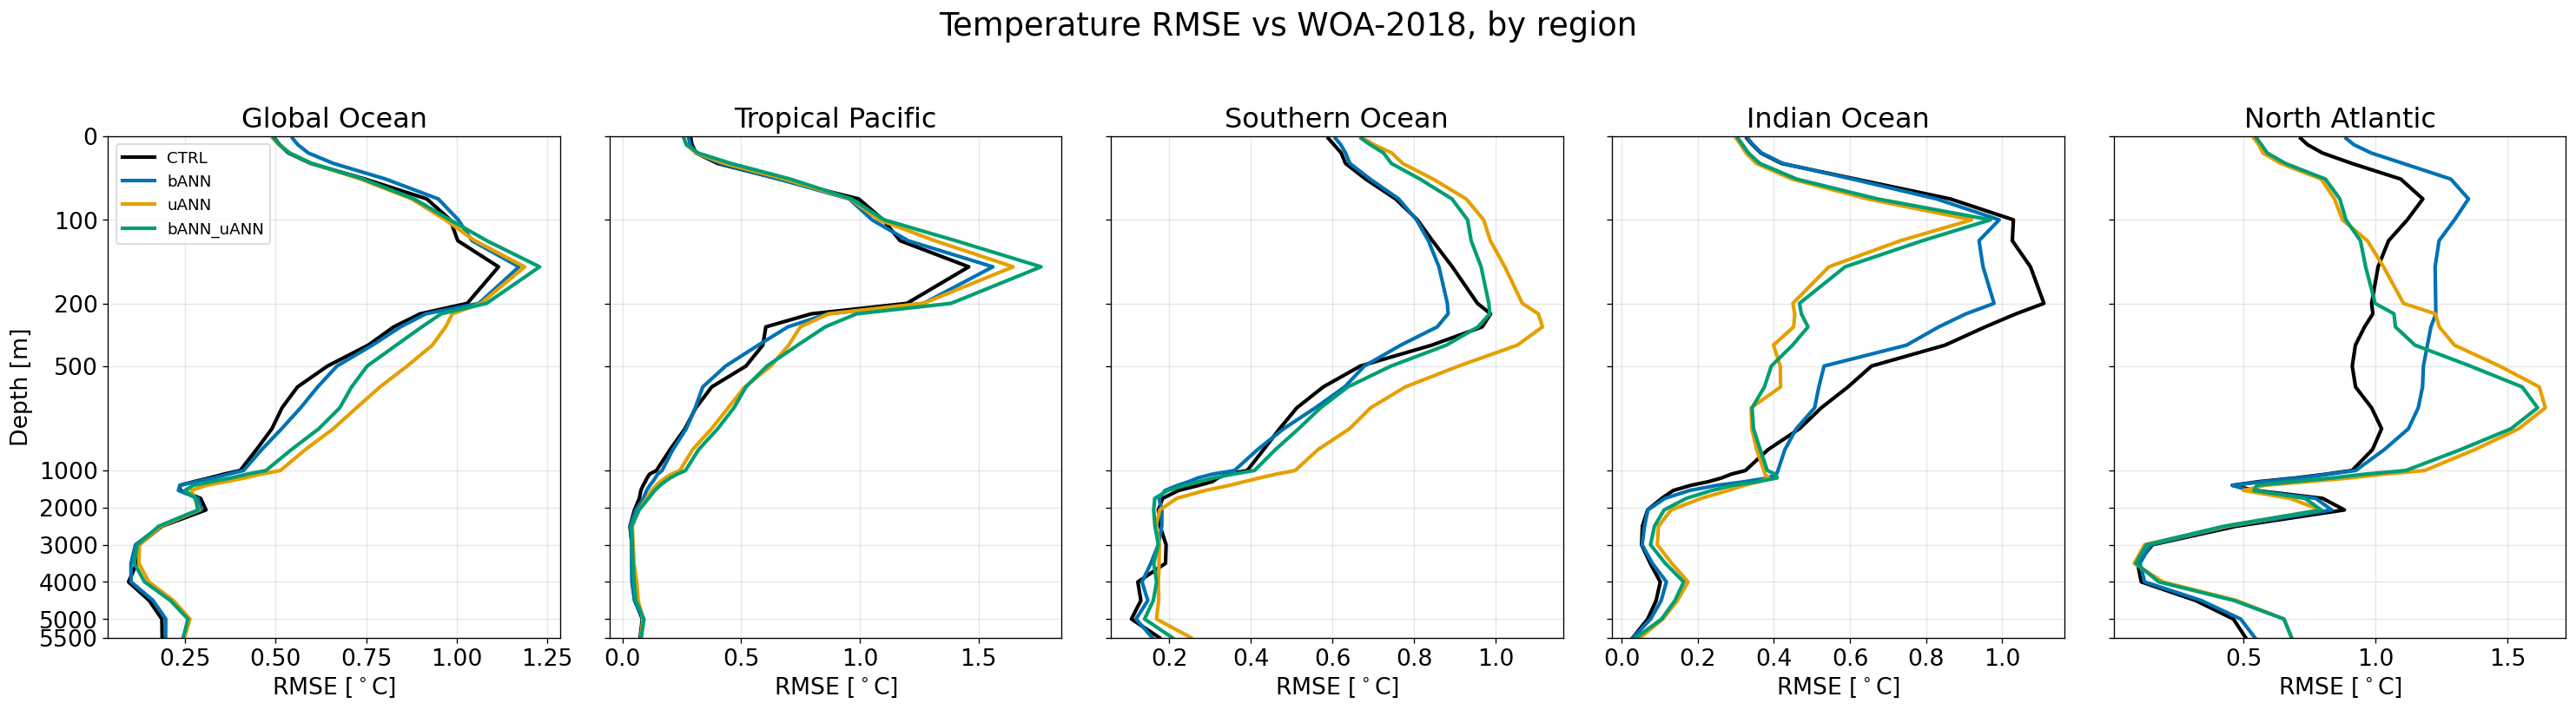

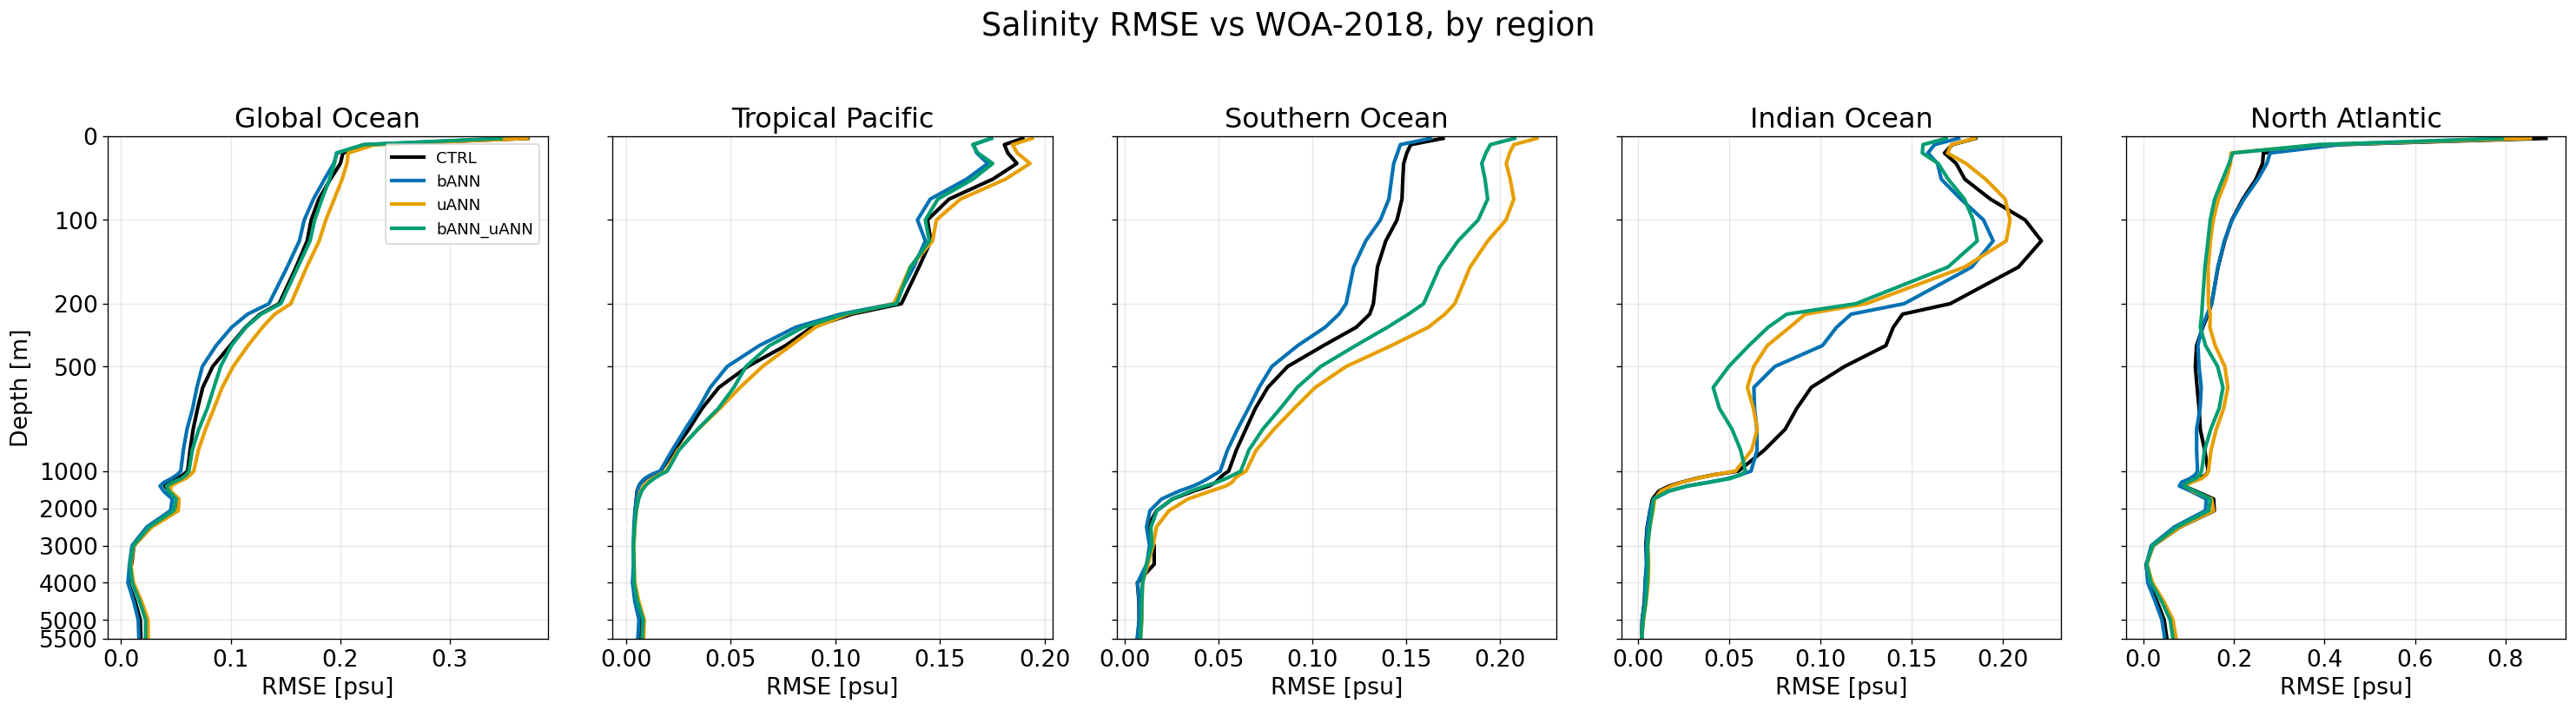

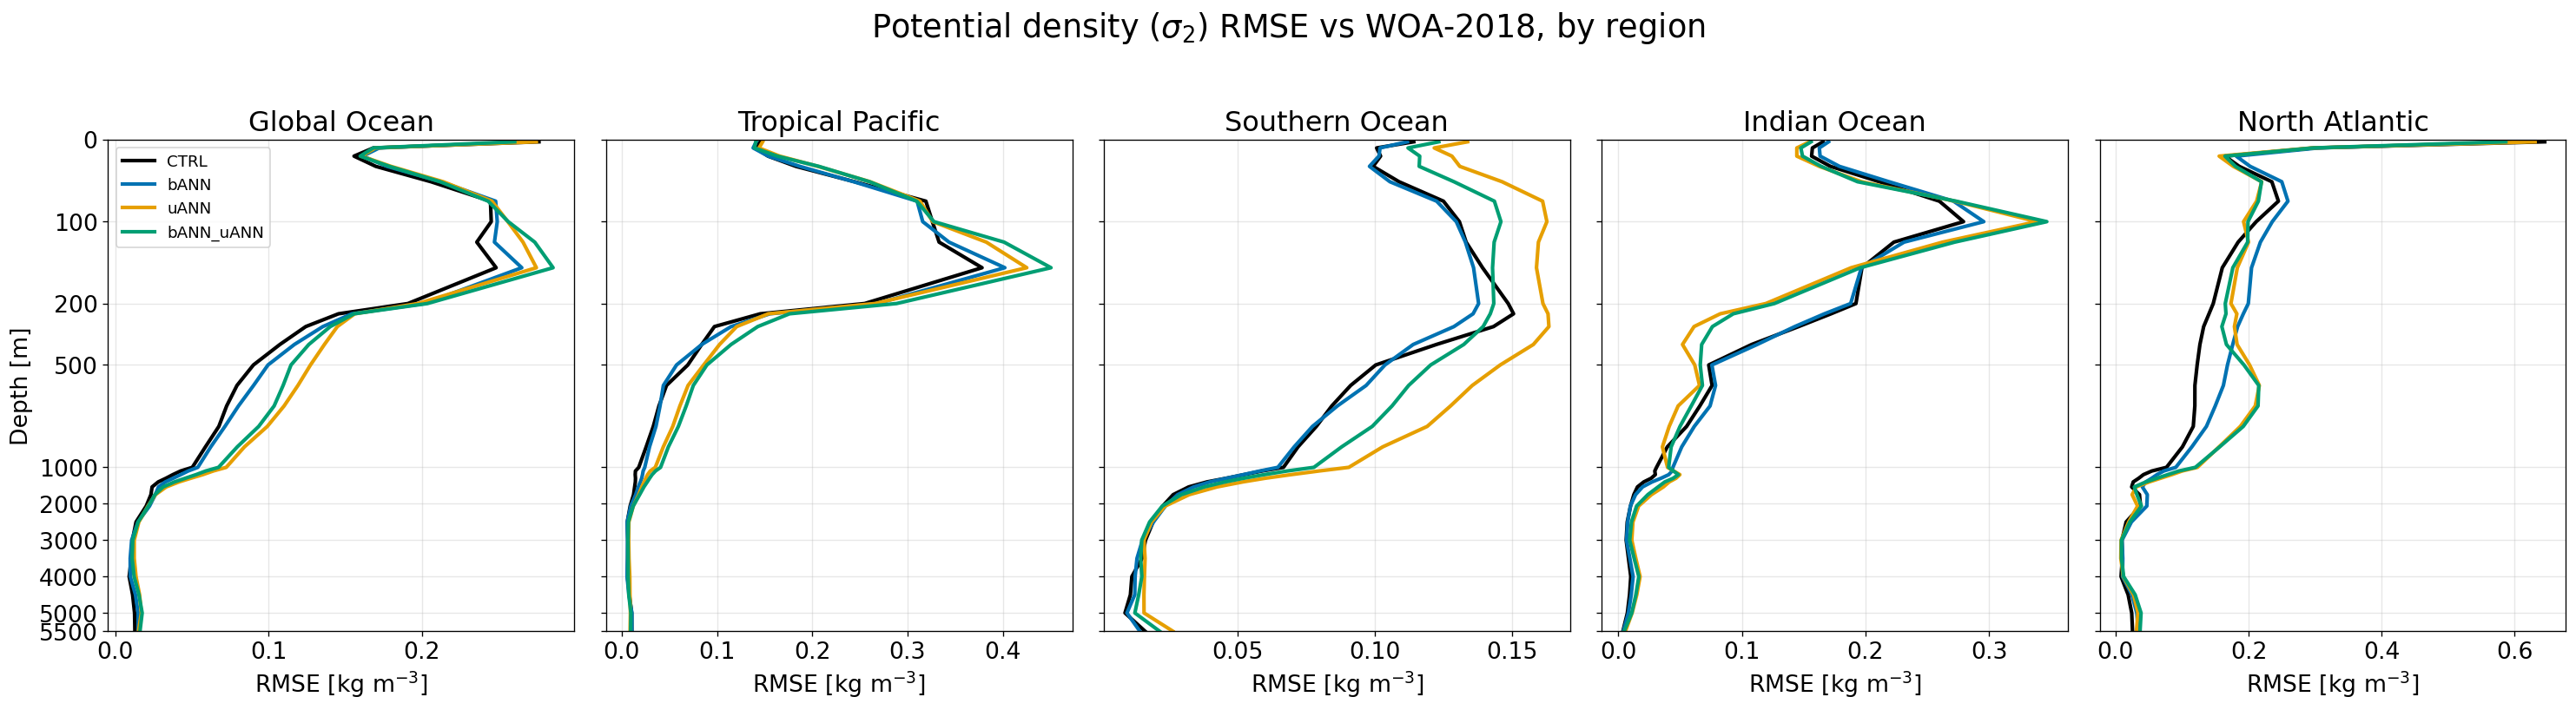

In [6]:
for var, long_name, unit in VARIABLES:
    plot_region_profiles(var, long_name, unit, mode='rmse')